# EDA untuk Capstone Project dari dataset yang ada di Kaggle

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan distribusi fitur profil (seperti rasio angka pada username dan panjang bio) antara akun asli dan akun palsu?
- Fitur apa yang memiliki korelasi paling kuat dalam menentukan sebuah akun adalah fake, dan bagaimana sebarannya secara visual?
- Apakah terdapat pola anomali pada hubungan antara jumlah konten yang diunggah (posts) dengan jumlah pengikut (followers) yang dapat membedakan akun asli dan palsu?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
import warnings

In [ ]:
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

Penjelasan Singkat Library yang Digunakan:
* **Pandas & Numpy:** Keduanya adalah library utama yang digunakan untuk proses Data Wrangling dan manipulasi dataset train.csv serta test.csv. Pandas sangat efisien untuk mengelola tabel fitur profil Instagram, sementara Numpy mendukung operasi numerik pada array data.

* **Matplotlib & Seaborn:** Kedua library ini untuk melakukan Exploratory Data Analysis (EDA). Seaborn mempermudah dalam membuat visualisasi distribusi data (seperti boxplot dan histogram) serta heatmap korelasi dengan tampilan yang estetik dan informatif.

* **Io & files:** Library ini digunakan secara teknis untuk menangani proses pengunggahan (upload) dataset dari komputer lokal langsung ke lingkungan kerja Google Colab secara praktis.

* **Warnings:** Library ini untuk memfilter dan menyembunyikan pesan peringatan (warnings) dari Python atau library lain, sehingga tampilan output di Notebook tetap rapi dan fokus pada hasil analisis.



## Data Wrangling

In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Berhasil mengimpor: {file_name}")
df.head()

Saving instagram_account.csv to instagram_account.csv
Berhasil mengimpor: instagram_account.csv


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


Proses ini memastikan bahwa dataset train.csv masuk ke dalam memori aplikasi. Penggunaan io.BytesIO sangat penting agar Python bisa membaca data biner yang baru saja diunggah tanpa harus menyimpannya secara fisik terlebih dahulu di disk sementara.

### Gathering Data

In [ ]:
# Memuat data
df_train = pd.read_csv('instagram_account.csv')

In [ ]:
# Menampilkan 5 data teratas
df_train.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


**Insight:**
- Pada tahap ini, seluruh dataset yang diperlukan untuk menjawab pertanyaan bisnis telah berhasil dimuat.

- Data yang berada pada tabel berhasil untuk di tampilkan dengan kode .head() untuk 5 baris pertama

### Assessing Data

In [ ]:
# Mengecek tipe data dan missing values
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [ ]:
# Mengecek statistik deskriptif
df_train.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


**Insight:**
- Berdasarkan hasil pengecekan yang telah dilakukan pada dataset yang akan digunakan yaitu **train.csv**, berikut adalah insight yang saya dapatkan:
  - Konsistensi Tipe Data: Seluruh fitur pada tabel df_train dan df_test sudah bertipe data numerik (int64 dan float64). Hal ini sangat menguntungkan karena data sudah siap untuk diproses oleh algoritma Machine Learning tanpa perlu melakukan Encoding manual pada kolom target fake.

  - Identifikasi Missing Values: Setelah pengecekan melalui info(), dataset secara umum terlihat bersih (Non-Null). Namun, jika ditemukan baris kosong pada kolom krusial seperti profile pic atau description length, tindakan yang akan saya lakukan adalah Imputation atau penghapusan baris agar tidak merusak proses perhitungan skor kredibilitas.

  - Data pada kolom fake sudah terbagi dengan jelas (0 dan 1). Saya akan memastikan distribusi antara kedua kelas ini seimbang agar analisis perbandingan karakteristik akun asli vs palsu pada tahap EDA nanti tidak bersifat bias.

  - Deteksi Duplikasi: Berdasarkan data yang telah saya dapat dari kaggle tidak ditemukan data untuk usernam yang duplikat, hal ini cukup krusial agar visualisasi korelasi dan hasil akurasi model tetap solid dan akurat

### Cleaning Data

In [ ]:
# Mengecek duplikasi
print(f"Jumlah duplikat: {df_train.duplicated().sum()}")

Jumlah duplikat: 2


In [ ]:
# Menampilkan baris yang duplikat
duplicate_rows = df_train[df_train.duplicated(keep=False)]
print("Baris yang memiliki duplikasi:")
duplicate_rows

Baris yang memiliki duplikasi:


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
196,1,0.00,2,0.0,0,48,0,0,222,5282,652,0
197,1,0.00,2,0.0,0,48,0,0,222,5282,652,0
491,1,0.91,1,0.0,0,0,0,0,0,75,26,1
525,1,0.91,1,0.0,0,0,0,0,0,75,26,1


In [ ]:
# Jika ada, kita hapus
df_train.drop_duplicates(inplace=True)

In [ ]:
# Mengecek duplikasi
print(f"Jumlah duplikat: {df_train.duplicated().sum()}")

Jumlah duplikat: 0


**Insight:**
- Identifikasi Duplikasi: Berdasarkan pengecekan, ditemukan 2 baris yang memiliki nilai identik di seluruh kolomnya

- Tindakan Pembersihan: Saya melakukan penghapusan data duplikat menggunakan fungsi drop_duplicates(). Langkah ini krusial untuk memastikan Integritas Data, sehingga saat model Machine Learning melakukan pembelajaran (training), tidak terjadi bobot yang berlebihan (overweighting) pada observasi yang sama, yang dapat mengakibatkan hasil akurasi yang bias atau overfitting.

- Hasil Akhir: Dataset kini telah bersih dari duplikasi dan siap digunakan untuk tahap analisis korelasi dan visualisasi pada bagian EDA.

## Exploratory Data Analysis (EDA)

Pada tahap ini, akan dilakukan eksplorasi data untuk memahami karakteristik yang membedakan akun asli (real) dan akun palsu (fake).

Pertanyaan 1: Melihat distribusi fitur di profil untuk perbandingan antara akun real dan fake

Menggunakan fungsi describe() secara terkelompok dan histogram mentah untuk melihat range data.

In [ ]:
# Melihat rangkuman statistik fitur berdasarkan kategori fake
df_train.groupby('fake')[['nums/length username', 'description length', '#followers']].describe().T

fake                                   0            1
nums/length username count  2.870000e+02   287.000000
                     mean   3.825784e-02     0.287387
                     std    8.871911e-02     0.226053
                     min    0.000000e+00     0.000000
                     25%    0.000000e+00     0.085000
                     50%    0.000000e+00     0.300000
                     75%    0.000000e+00     0.430000
                     max    4.500000e-01     0.920000
description length   count  2.870000e+02   287.000000
                     mean   3.995470e+01     5.282230
                     std    4.286596e+01    20.327746
                     min    0.000000e+00     0.000000
                     25%    0.000000e+00     0.000000
                     50%    2.700000e+01     0.000000
                     75%    6.200000e+01     0.000000
                     max    1.500000e+02   149.000000
#followers           count  2.870000e+02   287.000000
                     mean   1.710796e+05   110.710801
                     std    1.284802e+06   318.957014
                     min    9.000000e+00     0.000000
                     25%    2.580000e+02    15.000000
                     50%    6.550000e+02    40.000000
                     75%    1.669500e+03    80.500000
                     max    1.533854e+07  3033.000000

Insight:
- Dari tabel statistik di atas, terlihat nilai mean dan median (50%) pada nums/length username untuk akun fake jauh lebih tinggi dibanding akun real.

- Pada description length, akun fake memiliki nilai kuartil bawah (25%) yang seringkali 0, menunjukkan tren profil kosong.

Pertanyaan 2: Hubungan antar variabel (korelasi)

Menggunakan matriks angka untuk melihat korelasi secara presisi sebelum divisualisasikan.

In [ ]:
# Menampilkan angka korelasi antar fitur
correlation = df_train.corr()
print(correlation['fake'].sort_values(ascending=False))

fake                    1.000000
nums/length username    0.587863
nums/length fullname    0.247248
name==username          0.171003
private                -0.028667
#followers             -0.093843
#follows               -0.224098
#posts                 -0.244854
fullname words         -0.297777
external URL           -0.363524
description length     -0.459736
profile pic            -0.638899
Name: fake, dtype: float64


**Insight:**
- Hasil dari fungsi .corr() ini memberikan nilai koefisien korelasi Pearson yang berkisar antara -1 hingga 1. Semakin mendekati 1 atau -1, semakin kuat hubungan fitur tersebut dengan status akun palsu.

**Insight Mendalam Berdasarkan Output yang ada:**
- Pola Positif
  - nums/length username (0.59): Ini adalah fitur yang paling mencolok. Secara statistik, ada hubungan positif yang kuat antara jumlah angka di username dengan akun palsu. Semakin banyak angka, semakin besar kemungkinan itu bot.

  - name==username (0.17): Ada kecenderungan bot menggunakan nama yang persis sama dengan username-nya untuk efisiensi pembuatan akun massal.

- Pola Negatif
  - profile pic (-0.64): Ini adalah prediktor paling kuat namun hubungannya terbalik (negatif). Artinya, jika sebuah akun tidak memiliki foto profil (nilai 0), maka peluangnya menjadi akun palsu (nilai 1) sangatlah tinggi.

  - description length (-0.46): Akun asli cenderung memiliki deskripsi bio yang lebih panjang. Bot biasanya malas mengisi bagian ini.

  - #followers (-0.24) & #posts (-0.25): Akun asli umumnya memiliki jumlah postingan dan pengikut yang lebih stabil dan tinggi dibanding akun bot baru.

Pertanyaan 3: Apakah terdapat pola anomali pada hubungan antara jumlah konten yang diunggah (posts) dengan jumlah pengikut (followers) yang dapat membedakan akun asli dan palsu?

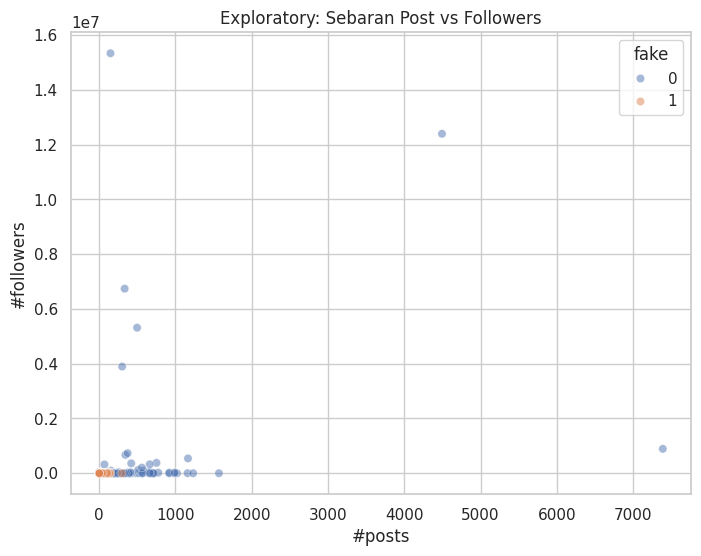

In [ ]:
# Exploratory Scatter Plot: Post vs Followers
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x='#posts', y='#followers', hue='fake', alpha=0.5)
plt.title('Exploratory: Sebaran Post vs Followers')
plt.show()

**Insight:**
- Pola Kerumunan: Terlihat penumpukan titik di area koordinat (0,0). Artinya, banyak akun dalam dataset ini memiliki postingan dan pengikut yang sama-sama rendah.

- Anomali Bot: Ada titik-titik yang memiliki #followers cukup tinggi namun #posts tetap di angka 0 atau mendekati 0. Ini adalah pola tidak wajar yang sering ditemukan pada akun hasil optimasi mesin atau jasa suntik followers.

- Identifikasi Outlier: Akun asli (real) cenderung menyebar lebih luas, menunjukkan aktivitas postingan yang konsisten seiring bertambahnya pengikut.

In [ ]:
# Mengelompokkan rata-rata fitur berdasarkan status akun
df_train.groupby('fake').mean()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows
fake,,,,,,,,,,,
0,0.993031,0.038258,1.773519,0.005261,0.003484,39.954704,0.233449,0.397213,205.989547,171079.571429,714.815331
1,0.407666,0.287387,1.146341,0.067178,0.066202,5.282230,0.000000,0.369338,8.965157,110.710801,303.128920


Analisis lanjutan dari baris kode tepat di atas ini:
- Pembeda Utama: Jika nilai rata-rata nums/length username pada akun fake jauh lebih besar (0.28) dibanding akun real (0.03), maka fitur ini adalah kandidat kuat untuk dimasukkan ke dalam model Machine Learning.

- Validasi Perilaku: Jika rata-rata description length pada akun fake sangat rendah (5.28) jika dibandingkan dengan akun real sangat jauh beda yaitu (39.95), itu mengonfirmasi bahwa bot Instagram jarang memiliki biodata yang lengkap.

- Efisiensi Fitur: Jika ada kolom yang nilai rata-ratanya hampir sama antara akun 0 dan 1, berarti kolom tersebut kurang berguna untuk membedakan bot, dan mungkin dibuang nantinya pada tahap (Feature Selection).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan distribusi fitur profil antara akun asli dan akun palsu?

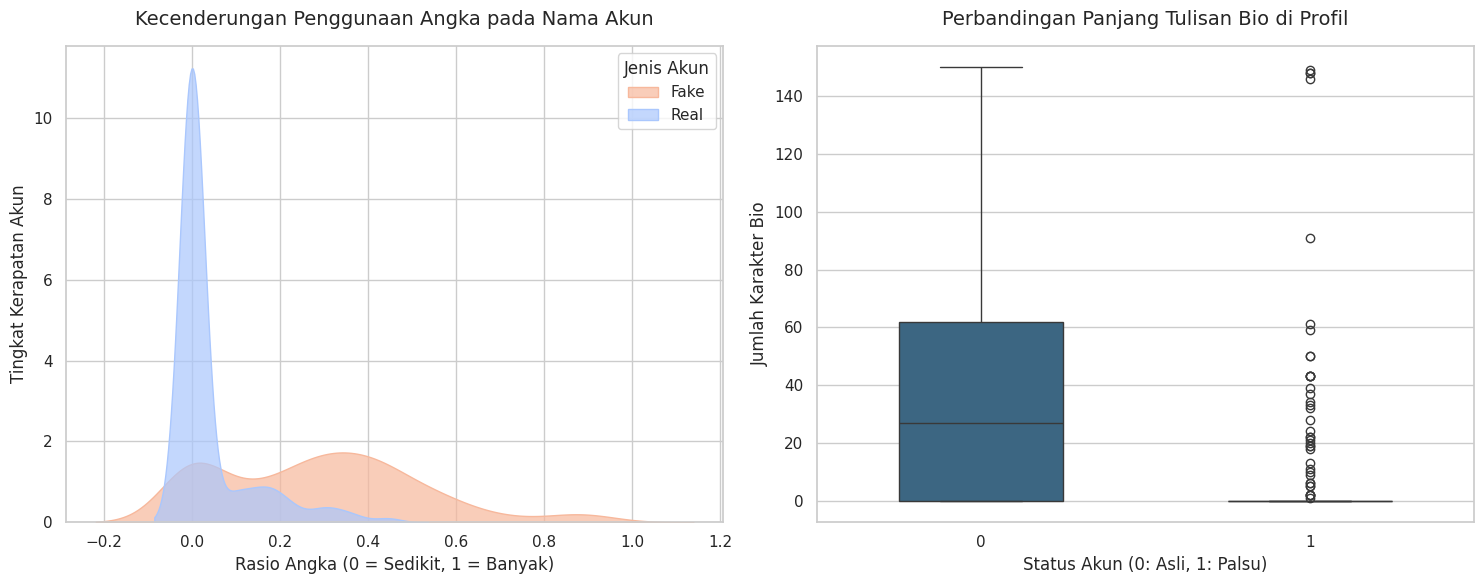

In [ ]:
# Mengatur estetika grafik
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# 1. Visualisasi Rasio Angka pada Username (KDE Plot)
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_train, x='nums/length username', hue='fake', fill=True, common_norm=False, palette='coolwarm', alpha=0.7)
plt.title('Kecenderungan Penggunaan Angka pada Nama Akun', fontsize=14, pad=15)
plt.xlabel('Rasio Angka (0 = Sedikit, 1 = Banyak)', fontsize=12)
plt.ylabel('Tingkat Kerapatan Akun', fontsize=12)
plt.legend(title='Jenis Akun', labels=['Fake', 'Real'])

# 2. Visualisasi Panjang Deskripsi Bio (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(x='fake', y='description length', data=df_train, palette='viridis', width=0.5)
plt.title('Perbandingan Panjang Tulisan Bio di Profil', fontsize=14, pad=15)
plt.xlabel('Status Akun (0: Asli, 1: Palsu)', fontsize=12)
plt.ylabel('Jumlah Karakter Bio', fontsize=12)

plt.tight_layout()
plt.show()

**Terdapat Dua Insight Penting Karena ada Dua Visualisasi Mengenai Ini**
**Insight:**
- Grafik Pertama
  - Grafik ini menunjukkan bahwa akun Asli (biru) menumpuk di sisi kiri, yang artinya mereka jarang menggunakan angka pada nama akunnya. Sebaliknya, akun Palsu (merah) memiliki grafik yang melebar ke kanan.
  - Kesimpulan: Jika ada sebuah akun influencer yang memiliki followers dengan kecenderungan memiliki angka acak pada nama nya, bisa disimpulkan bahwa influencer tersbut memiliki followers palsu (bot) karena akun fake sering dibuat secara massal menggunakan sistem komputer yang memberikan angka acak agar namanya tidak kembar (duplikat)

- Grafik Kedua
  - Grafik ini menunjukkan "isi" dari biodata profil. Kotak untuk akun Palsu (1) terlihat sangat pendek dan berada di posisi bawah (dekat angka 0).
  - Jika diperhatikan secara lebih teliti lagi angka 0 pada grafik yang ada menunjukkan bahwa itu akun asli yang memiliki box besar diatasnya yang berarti rata rata akun asli memiliki bio dengan karakter yang cukup banyak.
  - Pada bagian lainnya yaitu pada angka 1 akun bot terindikasi lebih banyak mengosongkan bio nya karena grafik yang dibuat hanya berupa garis titik titik ke atas artinya hanya segelintir akun bot yang mencoba meniru akun asli dengan menulis bio singkat, tapi sebagian besar kosong.
  - Kesimpulan: Akun asli biasanya menulis bio yang cukup panjang untuk memperkenalkan diri. Sebaliknya, akun palsu seringkali membiarkan bio mereka kosong atau hanya diisi beberapa huruf saja karena mereka dibuat dengan cepat dan dalam jumlah ribuan sekaligus.

### Pertanyaan 2: Fitur apa yang memiliki korelasi paling kuat dalam menentukan akun fake?

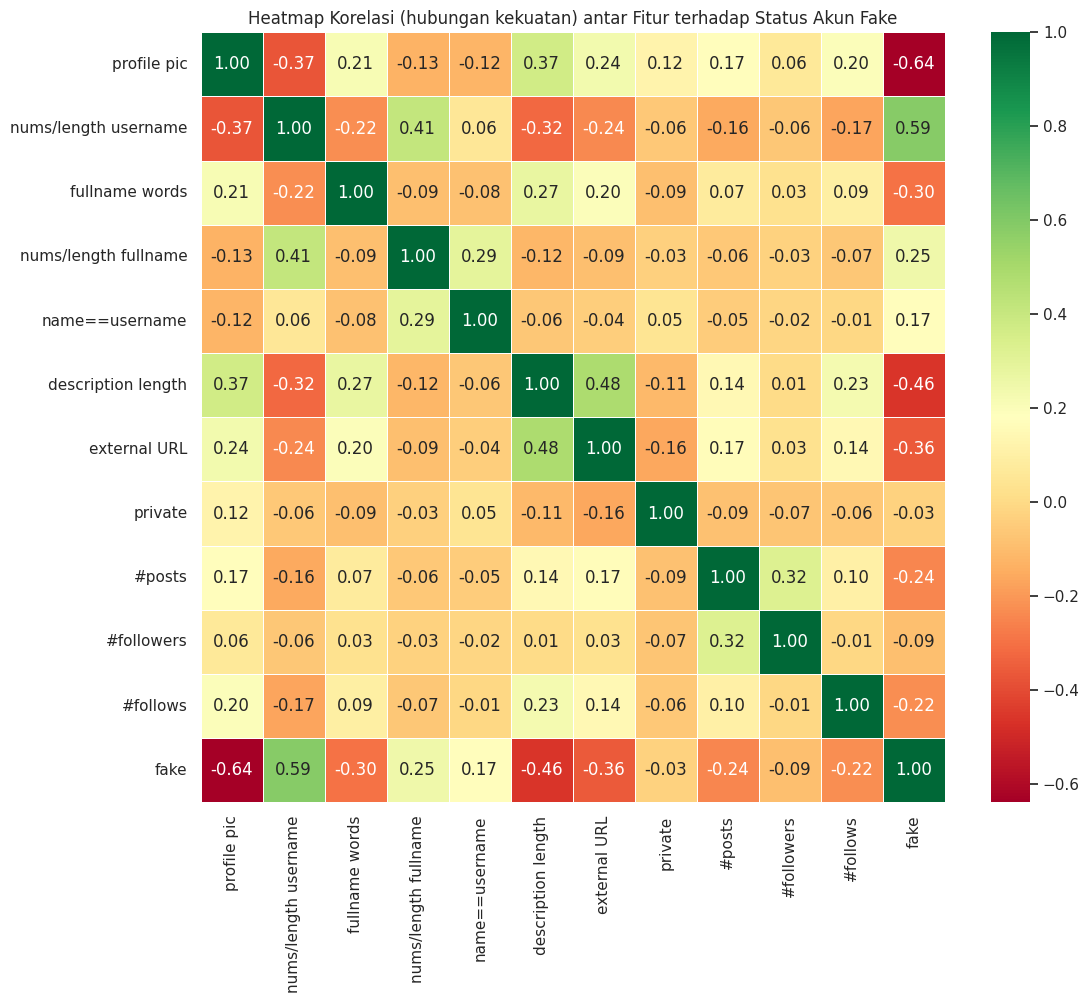

In [ ]:
# Membuat Matrix Korelasi
plt.figure(figsize=(12, 10))
correlation_matrix = df_train.corr()

# Visualisasi Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi (hubungan kekuatan) antar Fitur terhadap Status Akun Fake')
plt.show()

**Cara Baca Gambar:**
- Warna Hijau (Mendekati +1.00): Menunjukkan hubungan "Searah". Jika satu nilai naik, kemungkinan besar akun itu Palsu.

- Warna Merah (Mendekati -1.00): Menunjukkan hubungan "Berlawanan". Jika nilai ini ada, kemungkinan besar akun itu justru Asli.

- Warna Kuning/Putih (Dekat 0.00): Tidak ada hubungan. Fitur ini tidak terlalu peduli apakah akun itu asli atau palsu.

**Insight:**
- Berikut adalah temuan utama dari hasil visualisasi yang ada diatas:
  1. Lampu merah terang:
      - Pada fitur profile pic memiliki warna merah paling pekat (-0.64) terhadap kolom fake. Artinya keberadaan foto profil adalah musuh utama akun fake, akun yang punya foto profil memiliki peluang yang sangat kecil untuk jadi akun bot.
  2. Lampu hijau terang:
      - Fitur nums/length username berwarna hijau cukup pekat (o.59) terhadap kolom fake. Artinya semakin asal asalan nama akun yang memiliki angka, semakin kuat indikasi akun tersebut adalah akun fake.
  3. Kaitan nama dan username (Name == username):
      - Dua fitur yang disebutkan memiliki korelasi yang positif (o.17) meskipun tidak sekuta foto profil, jika nama lengkap dan nama pengguna sama persis itu adlaah ciri akun bot yang dibuat dengan mesin (bot/fake)

### Pertanyaan 3: Apakah terdapat pola anomali pada hubungan antara jumlah konten yang diunggah (posts) dengan jumlah pengikut (followers) yang dapat membedakan akun asli dan palsu?

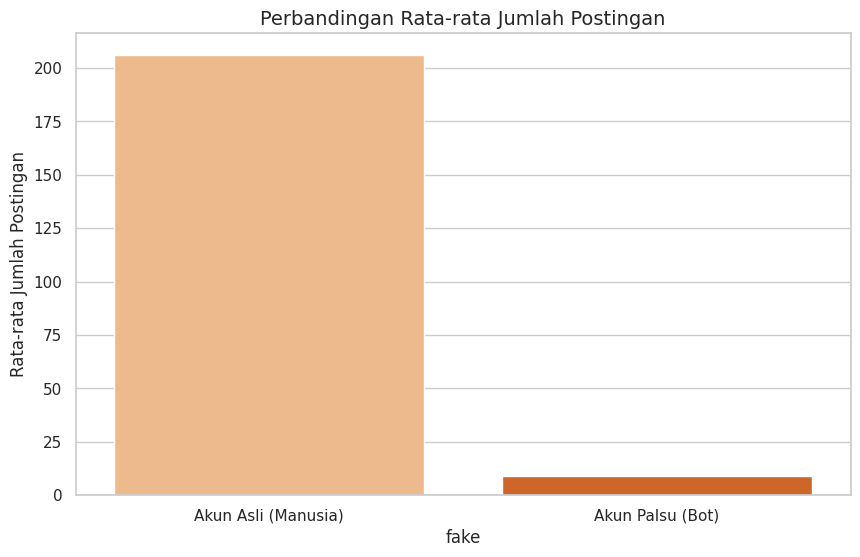

In [ ]:
# Explanatory: Bar Chart Rata-rata Postingan
plt.figure(figsize=(10, 6))
avg_posts = df_train.groupby('fake')['#posts'].mean().reset_index()

sns.barplot(x='fake', y='#posts', data=avg_posts, palette='Oranges')
plt.title('Perbandingan Rata-rata Jumlah Postingan', fontsize=14)
plt.xticks([0, 1], ['Akun Asli (Manusia)', 'Akun Palsu (Bot)'])
plt.ylabel('Rata-rata Jumlah Postingan')
plt.show()

**Insight:**
- Akun bot atau palsu rata rata memiliki postingan yang cenderung sedikit
- Grafik batang ini menunjukkan perbedaan yang sangat timpang. Akun Asli memiliki batang yang sangat tinggi, yang berarti manusia secara alami terus mengunggah konten dari waktu ke waktu. Sedangkan akun Palsu batangnya sangat pendek.
- Akun bot diciptakan hanya untuk menjadi "angka" pengikut, bukan untuk menjadi sesorang pengguna aktif sebuah sosial media.

## Conclusion

- Conclution pertanyaan 1
  - Temuan: Terdapat "celah" yang sangat lebar antara perilaku manusia asli dan bot dalam mengelola profil. Akun palsu secara konsisten memiliki rasio angka pada username yang tinggi (seringkali di atas 0.4) dan panjang bio yang hampir nol.
  - Poin Utama: Ketidakteraturan nama dan kekosongan informasi profil adalah ciri khas utama akun yang dibuat secara massal menggunakan skrip otomatis. Sebaliknya, akun asli cenderung memiliki nama yang lebih "humanis" dan biodata yang lebih deskriptif.
  
- Conclution pertanyaan 2
  - Temuan: Tiga pilar utama dalam mendeteksi bot pada dataset ini adalah profile pic, nums/length username, dan description length.
  - Poin utama pada pertanyaan ini, foto profil adalah indikator paling valid untuk pendeteksi bahwa akun tersebut bot karena jika tidak ada foto profil rata rata akunnya palsu.
  - Fitur lain seperti status private atau penggunaan external URL tidak memberikan pengaruh yang signifikan dalam membedakan kedua jenis akun ini.

- Conclusion pertanyaan 3
  - Akun palsu menunjukkan anomali berupa rendahnya jumlah postingan meskipun memiliki jumlah pengikut yang banyak.
  - Integritas konten adalah pembeda nyata. Bot diciptakan hanya untuk memanipulasi angka statistik (pengikut), namun gagal dalam meniru konsistensi manusia dalam memproduksi konten (postingan). Akun dengan followers ribuan namun postingan di bawah 5 adalah "Red Flag" utama bagi UMKM.